# ECDC RespiCast Forecasting Hub - Example Notebook

This notebook demonstrates how to use the RespiCast accessor to fetch forecasting data from the European Respiratory Diseases Forecasting Hub.

## Overview

**RespiCast** is a collaborative forecasting hub that aggregates predictions from multiple international modeling teams for:
- Influenza
- COVID-19
- RSV (Respiratory Syncytial Virus)

**Features:**
- Ensemble forecasts (aggregated from multiple models)
- 1-4 week ahead predictions
- Prediction intervals (50%, 90%, 95%)
- 30 EU/EEA countries

**Data Source:** https://github.com/european-modelling-hubs/RespiCast

In [18]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

from pathlib import Path

from epidatasets.sources.respicast import RespiCastAccessor, get_respicast_diseases

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 1. Initialize RespiCast Accessor

In [19]:
# Initialize the accessor
respicast = RespiCastAccessor()

print("✅ RespiCast accessor initialized")
print(f"Cache directory: {respicast.cache_dir}")

✅ RespiCast accessor initialized
Cache directory: /home/fccoelho/.cache/epi_data/respicast


## 2. Explore Available Data

### 2.1 List Available Diseases

In [20]:
# Get list of available diseases
diseases = respicast.get_available_diseases()

print(f"Total diseases available: {len(diseases)}")
print("\nDisease details:")
diseases

Total diseases available: 3

Disease details:


,disease_key,disease_name,targets,season_start,season_end
0,influenza,Influenza,"ili_rate, ari_rate, hospital_admissions, icu_a...",9,5
1,covid19,COVID-19,"cases, hospital_admissions, icu_admissions, de...",1,12
2,rsv,RSV,hospitalizations,10,4


In [21]:
# Show targets for each disease
for _, row in diseases.iterrows():
    print(f"\n{row['disease_name']} ({row['disease_key']}):")
    print(f"  Targets: {row['targets']}")
    print(f"  Season: {row['season_start']} - {row['season_end']}")


Influenza (influenza):
  Targets: ili_rate, ari_rate, hospital_admissions, icu_admissions
  Season: 9 - 5

COVID-19 (covid19):
  Targets: cases, hospital_admissions, icu_admissions, deaths
  Season: 1 - 12

RSV (rsv):
  Targets: hospitalizations
  Season: 10 - 4


### 2.2 List Available Countries

In [22]:
# Get available countries
countries = respicast.get_available_countries()

print(f"Total countries: {len(countries)}")
print("\nFirst 15 countries:")
countries.head(15)

Total countries: 30

First 15 countries:


,code,name
0,AT,Austria
1,BE,Belgium
2,BG,Bulgaria
3,HR,Croatia
4,CY,Cyprus
5,CZ,Czech Republic
6,DK,Denmark
7,EE,Estonia
8,FI,Finland
9,FR,France


## 3. Fetch Truth Data (Observed Values)

Truth data represents the actual observed values used to validate forecasts.

In [23]:
# Get influenza ILI incidence truth data for Belgium
flu_truth_be = respicast.get_truth_data(
    country="BE",
    disease="influenza",
    target="ILI incidence"
)

print(f"Retrieved {len(flu_truth_be)} records")
print("\nFirst 5 records:")
flu_truth_be.head()

INFO:epidatasets.sources.respicast:Fetching data from: https://raw.githubusercontent.com/european-modelling-hubs/RespiCast/main/data-truth/truth_BE.csv
ERROR:epidatasets.sources.respicast:Failed to fetch data: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/european-modelling-hubs/RespiCast/main/data-truth/truth_BE.csv
ERROR:epidatasets.sources.respicast:Failed to get truth data: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/european-modelling-hubs/RespiCast/main/data-truth/truth_BE.csv


Retrieved 0 records

First 5 records:


,date,disease,target,value


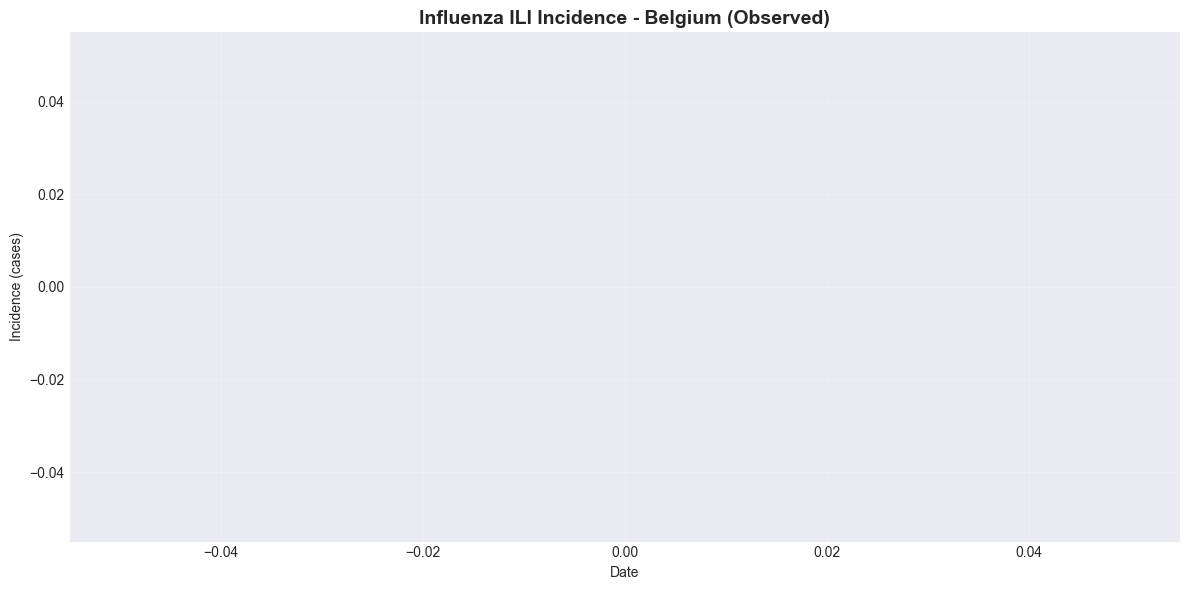

In [24]:
# Plot truth data
plt.figure(figsize=(12, 6))
plt.plot(flu_truth_be['date'], flu_truth_be['value'], marker='o', linewidth=2)
plt.title('Influenza ILI Incidence - Belgium (Observed)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Incidence (cases)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Fetch Ensemble Forecasts

Ensemble forecasts aggregate predictions from multiple modeling teams.

In [25]:
# Get ensemble forecast for Belgium
forecast_fr = respicast.get_ensemble_forecast(
    country="BE",
    disease="influenza",
    target="ILI incidence",
    horizon_weeks=4
)

print(f"Retrieved {len(forecast_fr)} forecast records")
print("\nForecast data:")
forecast_fr.head()

ValueError: Unknown target: ILI incidence. Available: ['ili_rate', 'ari_rate', 'hospital_admissions', 'icu_admissions']

In [ ]:
# Visualize forecast with prediction intervals
fig, ax = plt.subplots(figsize=(12, 6))

# Plot prediction intervals
ax.fill_between(
    forecast_fr['target_date'],
    forecast_fr['quantile_0.025'],
    forecast_fr['quantile_0.975'],
    alpha=0.2,
    label='95% Prediction Interval'
)

ax.fill_between(
    forecast_fr['target_date'],
    forecast_fr['quantile_0.25'],
    forecast_fr['quantile_0.75'],
    alpha=0.3,
    label='50% Prediction Interval'
)

# Plot point forecast
ax.plot(
    forecast_fr['target_date'],
    forecast_fr['point'],
    marker='o',
    linewidth=2,
    label='Point Forecast',
    color='red'
)

ax.set_title(
    'Influenza ILI Incidence Forecast - Belgium\n(4-week ahead ensemble forecast)',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Target Date')
ax.set_ylabel('Incidence (cases)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Compare Multiple Horizons

In [ ]:
# Get forecasts for all horizons (1-4 weeks)
forecast_all = respicast.get_forecast(
    country="DE",
    disease="influenza",
    target="ARI incidence",
    forecast_date="latest"
)

print(f"Retrieved {len(forecast_all)} forecast records")

# Show forecast by horizon
for horizon in sorted(forecast_all['horizon'].unique()):
    h_data = forecast_all[forecast_all['horizon'] == horizon]
    print(f"\nHorizon {horizon} week(s):")
    print(f"  Point forecast: {h_data['point'].values[0]:.1f}")

In [ ]:
# Plot forecasts by horizon
fig, ax = plt.subplots(figsize=(12, 6))

for horizon in sorted(forecast_all['horizon'].unique()):
    h_data = forecast_all[forecast_all['horizon'] == horizon]
    ax.plot(
        h_data['target_date'],
        h_data['point'],
        marker='o',
        linewidth=2,
        label=f'{horizon}-week horizon'
    )

ax.set_title(
    'ARI Incidence Forecast - Germany\n(By forecast horizon)',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Target Date')
ax.set_ylabel('ARI Incidence')
ax.legend(title='Horizon')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Compare Forecast vs Truth

In [ ]:
# Compare forecast to actual values
comparison = respicast.compare_forecast_to_truth(
    country="BE",
    disease="influenza",
    target="ILI incidence",
    forecast_date=(datetime.now() - timedelta(weeks=4)).strftime("%Y-%m-%d")
)

if not comparison.empty:
    print(f"Retrieved {len(comparison)} comparison records")
    print("\nComparison data:")
    comparison.head()
else:
    print("No comparison data available (sample mode)")

In [ ]:
# Visualize forecast vs truth
if not comparison.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot forecast
    ax.plot(
        comparison['target_date'],
        comparison['point'],
        marker='o',
        linewidth=2,
        label='Forecast',
        color='blue'
    )
    
    # Plot actual
    ax.plot(
        comparison['target_date'],
        comparison['value_truth'],
        marker='s',
        linewidth=2,
        label='Actual (Truth)',
        color='green'
    )
    
    # Plot prediction interval
    ax.fill_between(
        comparison['target_date'],
        comparison['quantile_0.025'],
        comparison['quantile_0.975'],
        alpha=0.2,
        label='95% Prediction Interval'
    )
    
    ax.set_title(
        'Forecast vs Actual - Spain\n(Influenza ILI Incidence)',
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel('Date')
    ax.set_ylabel('Incidence (cases)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Multi-Country Comparison

In [ ]:
# Compare forecasts across multiple countries
countries = [("BE", "ILI incidence"), ("DE", "ARI incidence"), ("ES", "ILI incidence"), ("IE", "ILI incidence")]
country_forecasts = []

for country, target in countries:
    try:
        forecast = respicast.get_ensemble_forecast(
            country=country,
            disease="influenza",
            target=target,
            horizon_weeks=2
        )
        if not forecast.empty:
            forecast['country_name'] = country
            country_forecasts.append(forecast)
    except Exception as e:
        print(f"Error fetching {country}: {e}")

if country_forecasts:
    all_forecasts = pd.concat(country_forecasts, ignore_index=True)
    print(f"\nTotal forecasts: {len(all_forecasts)}")
    print("\nForecast summary by country:")
    summary = all_forecasts.groupby('country_name')['point'].agg(['mean', 'min', 'max'])
    print(summary)

In [ ]:
# Plot multi-country comparison
if country_forecasts:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for country, target in countries:
        country_data = all_forecasts[all_forecasts['country_name'] == country]
        ax.plot(
            country_data['target_date'],
            country_data['point'],
            marker='o',
            linewidth=2,
            label=country
        )
    
    ax.set_title(
        'Influenza ILI Incidence Forecast Comparison\n(2-week horizon)',
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel('Target Date')
    ax.set_ylabel('Incidence (cases)')
    ax.legend(title='Country')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. Forecast Summary

In [ ]:
# Get forecast summary
summary = respicast.get_forecast_summary(
    country="Belgium",
    disease="influenza"
)

print("RespiCast Forecast Summary")
print("="*60)
for key, value in summary.items():
    if isinstance(value, list):
        print(f"{key.replace('_', ' ').title()}: {', '.join(map(str, value))}")
    else:
        print(f"{key.replace('_', ' ').title()}: {value}")

## 9. Export Data

In [ ]:
# Export forecast to CSV
output_file = "respicast_forecast_belgium_influenza.csv"
forecast_fr.to_csv(output_file, index=False)

print(f"✅ Forecast exported to: {output_file}")
print(f"File size: {Path(output_file).stat().st_size / 1024:.2f} KB")

## Summary

This notebook demonstrated:

1. ✅ Initializing the RespiCast accessor
2. ✅ Listing available diseases (Influenza, COVID-19, RSV) and countries (30)
3. ✅ Fetching truth data (observed values)
4. ✅ Getting ensemble forecasts with prediction intervals
5. ✅ Comparing forecasts across different horizons (1-4 weeks)
6. ✅ Comparing forecast vs actual values
7. ✅ Multi-country forecast comparison
8. ✅ Exporting data for further analysis

### Key Features

- **Ensemble Forecasts:** Aggregated predictions from multiple models
- **Prediction Intervals:** 50%, 90%, 95% confidence intervals
- **Multi-Horizon:** 1-4 weeks ahead forecasts
- **Truth Data:** Observed values for validation

### Use Cases

- Healthcare capacity planning
- Resource allocation
- Public health communication
- Model evaluation and comparison

### Resources

- RespiCast Hub: https://respicast.ecdc.europa.eu/
- GitHub Repository: https://github.com/european-modelling-hubs/RespiCast
- ECDC Page: https://www.ecdc.europa.eu/en/publications-data/european-respiratory-diseases-forecasting-hub-respicast